<a href="https://colab.research.google.com/github/saravianelson/-riviera-barber-analytics/blob/master/notebooks/Riviera_Barber_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💈 Riviera Barber — Operational Analytics
**Author:** Nelson Saravia  
**Project:** Data-Driven Barbershop Management

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
from google.colab import files
import io

print('✅ Entorno listo')

✅ Entorno listo


## 1. Carga y Limpieza Automática
Este proceso limpia los símbolos de moneda, rellena fechas faltantes y recalcula comisiones (60/40).

In [ ]:
def clean_data(df):
    df = df.copy()
    df['Fecha'] = df['Fecha'].replace('', np.nan).ffill()
    df = df[df['Tipo'] == 'Ingreso']

    money_cols = ['Monto', 'Propina', 'Comisión_Barbero', 'Neto_Negocio']
    for col in money_cols:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[$,]', '', regex=True), errors='coerce').fillna(0)

    df = df[df['Monto'] > 0]
    df['Comisión_Barbero'] = (df['Monto'] * 0.60).round(2)
    df['Neto_Negocio'] = (df['Monto'] * 0.40).round(2)
    df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)
    return df



# Selecciona el archivo de tu PC
uploaded = files.upload()

# Usamos el nombre del archivo que subiste
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df_clean = clean_data(df)
print(f'✅ Datos cargados: {len(df_clean)} servicios registrados.')

Saving CAJA_Limpia.csv to CAJA_Limpia (1).csv
✅ Datos cargados: 28 servicios registrados.


## 2. Generación Automática de Cierre Diario
Corrige los errores de la tabla manual y genera un reporte exacto por fecha.

In [ ]:
def generar_cierre(fecha_str):
    fecha = pd.to_datetime(fecha_str, dayfirst=True)
    dia = df_clean[df_clean['Fecha'] == fecha]

    reporte = {
        'Ventas Efectivo': dia[dia['Método_Pago'] == 'Efectivo']['Monto'].sum(),
        'Ventas Digital': dia[dia['Método_Pago'].isin(['Tarjeta', 'Transferencia'])]['Monto'].sum(),
        'Total Bruto': dia['Monto'].sum(),
        'Comisiones Nelson': dia['Comisión_Barbero'].sum(),
        'Propinas Nelson': dia['Propina'].sum(),
        'Utilidad Neta Negocio': dia['Neto_Negocio'].sum()
    }
    return pd.Series(reporte)

last_date = df_clean['Fecha'].max()
print(f'Reporte de Cierre para: {last_date.date()}')
print(generar_cierre(last_date))

Reporte de Cierre para: 2026-04-25
Ventas Efectivo           300.0
Ventas Digital           2100.0
Total Bruto              2400.0
Comisiones Nelson        1440.0
Propinas Nelson             0.0
Utilidad Neta Negocio     960.0
dtype: float64


## 3. Visualización de Negocio

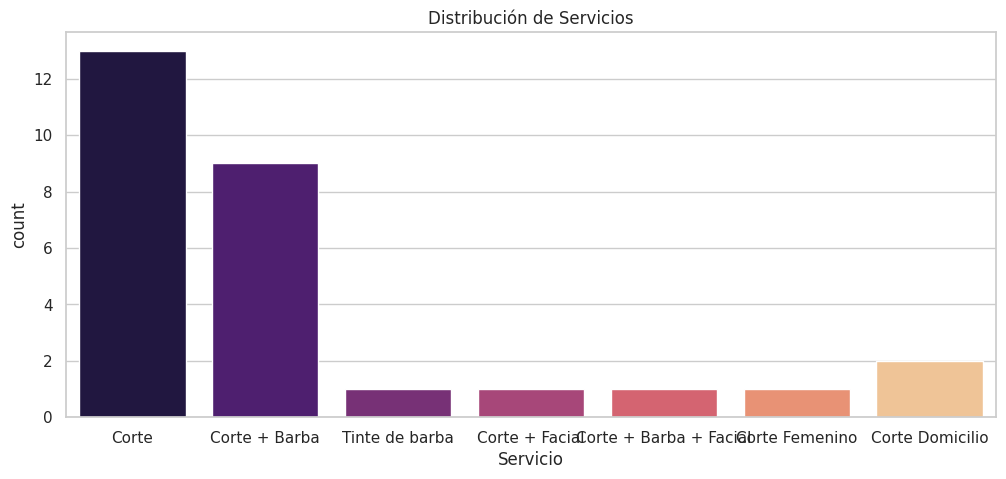

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data=df_clean, x='Servicio', palette='magma')
plt.title('Distribución de Servicios')
plt.show()